# Executive Summary

PureGym operates in a highly competitive fitness market where member retention and satisfaction are critical to long-term success.

This project applies Natural Language Processing (NLP) techniques to analyze negative customer reviews collected from Google Reviews and Trustpilot.

Key findings:
- Equipment availability and maintenance
- Staff behaviour and customer service
- Facilities, cleanliness, and membership-related issues

The agreement between BERTopic, LLM-enhanced topic modelling, and Gensim LDA increases confidence in the findings and highlights clear priorities for improving member satisfaction.

# 1. Business Context

## Project Objective
Analyse PureGym's review data to uncover key drivers that provide actionable insights for enhancing customer experience.

## Data Sources
- Google Reviews
- Trustpilot Reviews

# 2. Data Preparation and word clouds


## Load Datasets


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [ ]:
!pip install gdown xlrd
import gdown
import os

# Shared folder ID (from your link)
folder_id = "1azch13dtGeAkbnEjqeoyl3nU9jheojU4"

# gdown command to download the entire folder
!gdown --folder https://drive.google.com/drive/folders/{folder_id} -O datasets

Retrieving folder contents
Processing file 13TeZTT6oqk3iPELBhFx9hComIfChKw4m Google_12_months.xlsx
Processing file 1V6Pr6xWrHSHaothB61MJbR7mPFHwQ1u6 Trustpilot_12_months.xlsx
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=13TeZTT6oqk3iPELBhFx9hComIfChKw4m
To: /content/datasets/Google_12_months.xlsx
100% 2.08M/2.08M [00:00<00:00, 83.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1V6Pr6xWrHSHaothB61MJbR7mPFHwQ1u6
To: /content/datasets/Trustpilot_12_months.xlsx
100% 2.83M/2.83M [00:00<00:00, 40.1MB/s]
Download completed


In [ ]:
import pandas as pd

# xls to data frame
df_google = pd.read_excel("/content/datasets/Google_12_months.xlsx", engine="openpyxl")
df_tpilot = pd.read_excel("/content/datasets/Trustpilot_12_months.xlsx", engine="openpyxl")

In [ ]:
df_google.head()


,Customer Name,SurveyID for external use (e.g. tech support),Club's Name,Social Media Source,Creation Date,Comment,Overall Score
0,**,ekkt2vyxtkwrrrfyzc5hz6rk,Leeds City Centre North,Google Reviews,2024-05-09 23:49:18,NaN,4
1,**,e9b62vyxtkwrrrfyzc5hz6rk,Cambridge Leisure Park,Google Reviews,2024-05-09 22:48:39,Too many students from two local colleges go h...,1
2,**,e2dkxvyxtkwrrrfyzc5hz6rk,London Holborn,Google Reviews,2024-05-09 22:08:14,"Best range of equipment, cheaper than regular ...",5
3,**,e3tfxvyxtkwrrrfyzc5hz6rk,Cheshunt Brookfield Shopping Park,Google Reviews,2024-05-09 21:58:07,"Good gym when it’s not busy, tend to get too b...",4
4,**,edkrxvyxtkwrrrfyzc5hz6rk,Bristol Union Gate,Google Reviews,2024-05-09 21:48:00,"(current member)\n\nGym is quite dirty, more o...",1


In [ ]:
df_tpilot.head()

,Review ID,Review Created (UTC),Review Consumer User ID,Review Title,Review Content,Review Stars,Source Of Review,Review Language,Domain URL,Webshop Name,Business Unit ID,Tags,Company Reply Date (UTC),Location Name,Location ID
0,663d40378de0a14c26c2f63c,2024-05-09 23:29:00,663d4036d5fa24c223106005,A very good environment,A very good environment,5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,2024-05-10 08:12:00,Solihull Sears Retail Park,7b03ccad-4a9d-4a33-9377-ea5bba442dfc
1,663d3c101ccfcc36fb28eb8c,2024-05-09 23:11:00,5f5e3434d53200fa6ac57238,I love to be part of this gym,I love to be part of this gym. Superb value fo...,5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,2024-05-10 08:13:00,Aylesbury,612d3f7e-18f9-492b-a36f-4a7b86fa5647
2,663d375859621080d08e6198,2024-05-09 22:51:00,57171ba90000ff000a18f905,Extremely busy,"Extremely busy, no fresh air.",1,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,Sutton Times Square,0b78c808-f671-482b-8687-83468b7b5bc1
3,663d4fa1f25670a3339ccf6d,2024-05-09 22:35:00,663d4fa0d5fa24251d1068e7,Great vibes,"Great vibes, fantastic gym",5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,NaT,London Finchley,bc3a9a8c-defe-47b3-8ee6-f73a03b7447e
4,663d3251d8367b7b3c4ace64,2024-05-09 22:30:00,60c20598384d84001a4250de,Everything it needs to be,"Clean, well managed, classes are good.",5,AFSv2,en,http://www.puregym.com,PureGym UK,508df4ea00006400051dd7b1,NaN,2024-05-10 08:14:00,Crayford,9ce470b7-57df-4533-af2f-c539422fed14


In [ ]:
df_google.dropna(subset=['Comment'], inplace=True)
df_tpilot.dropna(subset=['Review Content'], inplace=True)

In [ ]:
print(df_google.shape)
print(df_tpilot.shape)

(13898, 7)
(16673, 15)


In [ ]:
cols_to_remove_google = ["Customer Name", "SurveyID for external use (e.g. tech support)", "Creation Date"]
df_google.drop(columns=cols_to_remove_google, inplace=True)

cols_to_remove_tpilot = ["Review ID", "Review Consumer User ID", "Review Language", "Domain URL","Webshop Name","Business Unit ID", "Tags", "Location ID", "Review Created (UTC)", "Company Reply Date (UTC)"]
df_tpilot.drop(columns=cols_to_remove_tpilot, inplace=True)

## Select Common Locations


In [ ]:
#Count how many unique values
df_google["Club's Name"].nunique()

512

In [ ]:
df_tpilot["Location Name"].nunique()

376

In [ ]:
#count how many common locations
common_locations = set(df_google["Club's Name"]).intersection(set(df_tpilot["Location Name"]))
print("Number of common locations:", len(common_locations))

Number of common locations: 310


In [ ]:
#Add a column marking whether each location is common
df_google["is_common"] = df_google["Club's Name"].isin(common_locations).astype(int)
df_tpilot["is_common"] = df_tpilot["Location Name"].isin(common_locations).astype(int)

In [ ]:
df_google.head()

,Club's Name,Social Media Source,Comment,Overall Score,is_common
1,Cambridge Leisure Park,Google Reviews,Too many students from two local colleges go h...,1,1
2,London Holborn,Google Reviews,"Best range of equipment, cheaper than regular ...",5,1
3,Cheshunt Brookfield Shopping Park,Google Reviews,"Good gym when it’s not busy, tend to get too b...",4,1
4,Bristol Union Gate,Google Reviews,"(current member)\n\nGym is quite dirty, more o...",1,1
5,"209 - Slagelse, Jernbanegade",Google Reviews,Kom og betalte for en prøvetime i centret. Fik...,1,0


In [ ]:
df_tpilot.head()

,Review Title,Review Content,Review Stars,Source Of Review,Location Name,is_common
0,A very good environment,A very good environment,5,AFSv2,Solihull Sears Retail Park,0
1,I love to be part of this gym,I love to be part of this gym. Superb value fo...,5,AFSv2,Aylesbury,1
2,Extremely busy,"Extremely busy, no fresh air.",1,AFSv2,Sutton Times Square,1
3,Great vibes,"Great vibes, fantastic gym",5,AFSv2,London Finchley,1
4,Everything it needs to be,"Clean, well managed, classes are good.",5,AFSv2,Crayford,0


In [ ]:
#Selecting only common locations
df_google_common = df_google[df_google['is_common'] == 1]
df_tpilot_common = df_tpilot[df_tpilot['is_common'] == 1]

In [ ]:
print(df_tpilot_common.shape)
print(df_google_common.shape)

(9158, 6)
(10615, 5)


## Data cleaning


In [ ]:
#Install and import nltk define preprocess function
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re

stop_words = set(stopwords.words('english'))
gym_words = {"gym", "puregym"}
stop_words = stop_words.union(gym_words)


def preprocess_text(text):

    text = text.lower()
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return " ".join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
#Apply pre processing to google data frame
df_google_common['clean_review'] = df_google_common['Comment'].astype(str).apply(preprocess_text)
df_google_common[['Comment', 'clean_review']].head()

,Comment,clean_review
1,Too many students from two local colleges go h...,many students two local colleges go leave rubb...
2,"Best range of equipment, cheaper than regular ...",best range equipment cheaper regular gyms prof...
3,"Good gym when it’s not busy, tend to get too b...",good busy tend get busy late afternoon hardly ...
4,"(current member)\n\nGym is quite dirty, more o...",current member quite dirty often soap bathroom...
7,This gym is way too hot to even workout in. Th...,way hot even workout windows open ac barely wo...


In [ ]:
#Apply pre processing to Trustpilot data frame
df_tpilot_common['clean_review'] = df_tpilot_common['Review Content'].astype(str).apply(preprocess_text)
df_tpilot_common[['Review Content', 'clean_review']].head()

,Review Content,clean_review
1,I love to be part of this gym. Superb value fo...,love part superb value money time day love app...
2,"Extremely busy, no fresh air.",extremely busy fresh air
3,"Great vibes, fantastic gym",great vibes fantastic
7,Great gym felt very comfortable enjoyed my ses...,great felt comfortable enjoyed sessions
9,"Fun, worth the work out.",fun worth work


[('equipment', 2928), ('good', 2865), ('great', 2851), ('staff', 2145), ('classes', 1987), ('clean', 1450), ('always', 1398), ('friendly', 1395), ('machines', 1387), ('really', 1274)]


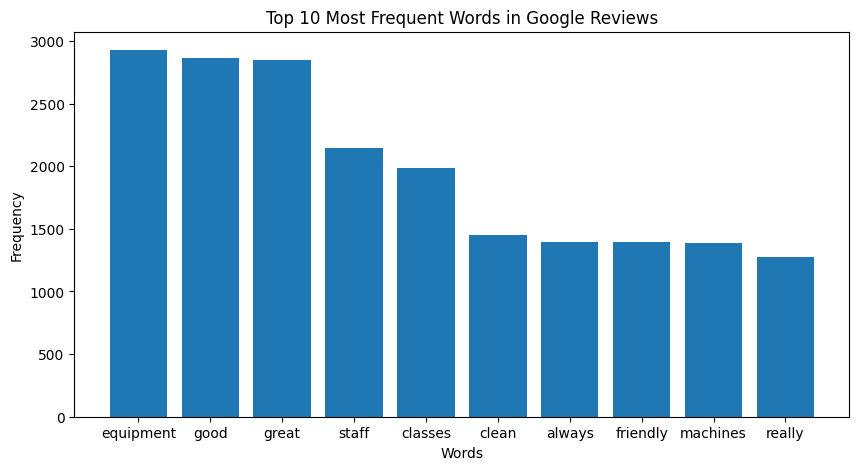

In [ ]:
from nltk import FreqDist
import matplotlib.pyplot as plt

# Split clean_review into tokens
all_words_g = " ".join(df_google_common['clean_review']).split()

# Create frequency distribution
freq_dist_g = FreqDist(all_words_g)

print(freq_dist_g.most_common(10))

# Get top 10 words
top_words_g = freq_dist_g.most_common(10)
words, counts = zip(*top_words_g)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words in Google Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()


[('equipment', 2981), ('good', 2553), ('great', 2491), ('staff', 2434), ('friendly', 1685), ('classes', 1664), ('clean', 1655), ('machines', 1184), ('always', 1178), ('really', 1114)]


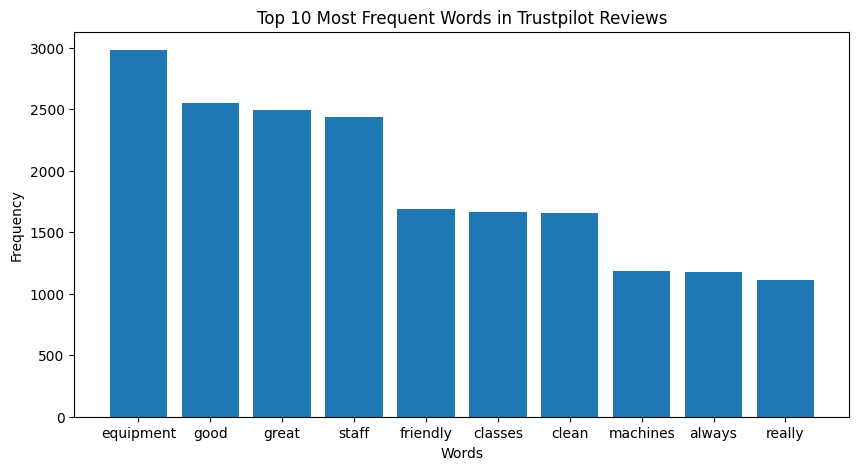

In [ ]:
# Split clean_review into tokens
all_words_tp = " ".join(df_tpilot_common['clean_review']).split()

# Create frequency distribution
freq_dist_tp = FreqDist(all_words_tp)

print(freq_dist_tp.most_common(10))

# Get top 10 words
top_words_tp = freq_dist_tp.most_common(10)
words, counts = zip(*top_words_tp)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words in Trustpilot Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

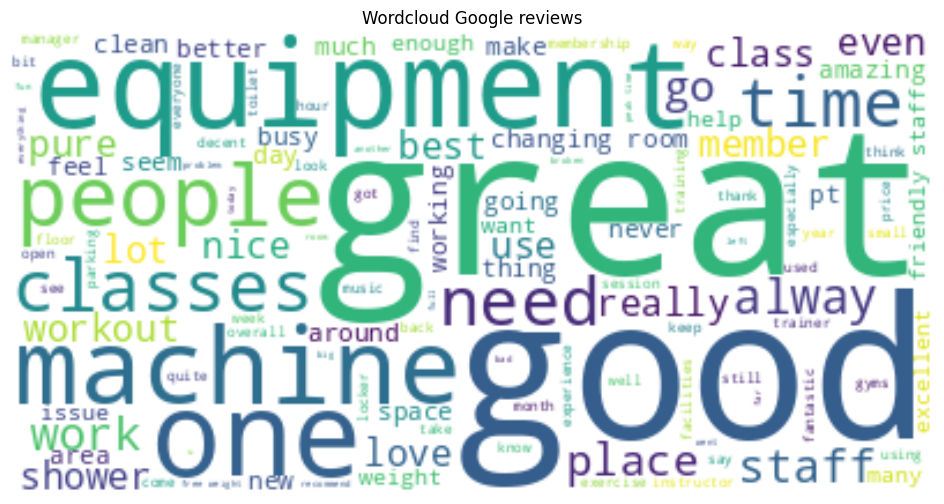

In [ ]:
!pip install wordcloud pillow numpy

import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt


# Join all cleaned reviews
text_goo = " ".join(df_google_common['clean_review'])

# Create word cloud
wordcloud_goo = WordCloud(
    background_color="white",
    contour_color="black",
    contour_width=2
).generate(text_goo)

# Plot
plt.figure(figsize=(12,6))
plt.title("Wordcloud Google reviews")
plt.imshow(wordcloud_goo, interpolation="bilinear")
plt.axis("off")
plt.show()


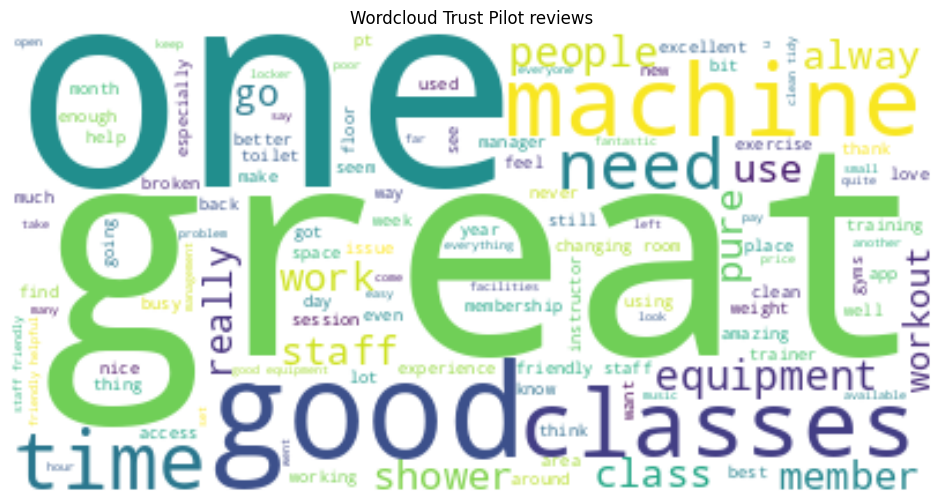

In [ ]:
# Join all cleaned reviews
text_tp = " ".join(df_tpilot_common['clean_review'])

# Create word cloud
wordcloud_tp = WordCloud(
    background_color="white",
    contour_color="black",
    contour_width=2
).generate(text_tp)

# Plot
plt.figure(figsize=(12,6))
plt.title("Wordcloud Trust Pilot reviews")
plt.imshow(wordcloud_tp, interpolation="bilinear")
plt.axis("off")
plt.show()


## Negative reviews filtering

In [ ]:
#keep only negative reviews
df_google_negative = df_google_common[df_google_common['Overall Score'] < 3]
df_tpilot_negative = df_tpilot_common[df_tpilot_common['Review Stars'] < 3]

print(df_google_negative.shape)
print(df_tpilot_negative.shape)

(2098, 6)
(1852, 7)


[('equipment', 770), ('staff', 588), ('people', 499), ('machines', 471), ('one', 466), ('time', 441), ('get', 392), ('like', 384), ('even', 347), ('place', 322)]


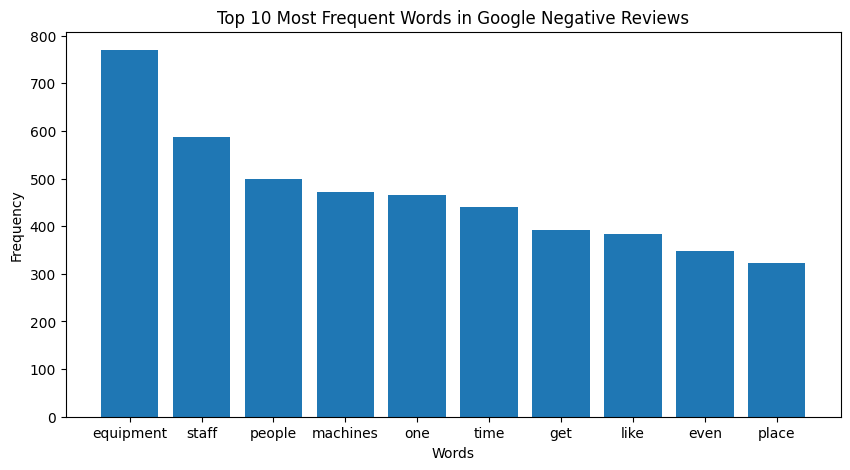

In [ ]:
# Split clean_review into tokens
all_words_g_neg = " ".join(df_google_negative['clean_review']).split()

# Create frequency distribution
freq_dist_g_neg = FreqDist(all_words_g_neg)

print(freq_dist_g_neg.most_common(10))

# Get top 10 words
top_words_g_neg = freq_dist_g_neg.most_common(10)
words, counts = zip(*top_words_g_neg)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words in Google Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

[('equipment', 538), ('staff', 443), ('one', 429), ('time', 371), ('get', 370), ('people', 365), ('machines', 335), ('membership', 313), ('use', 297), ('like', 292)]


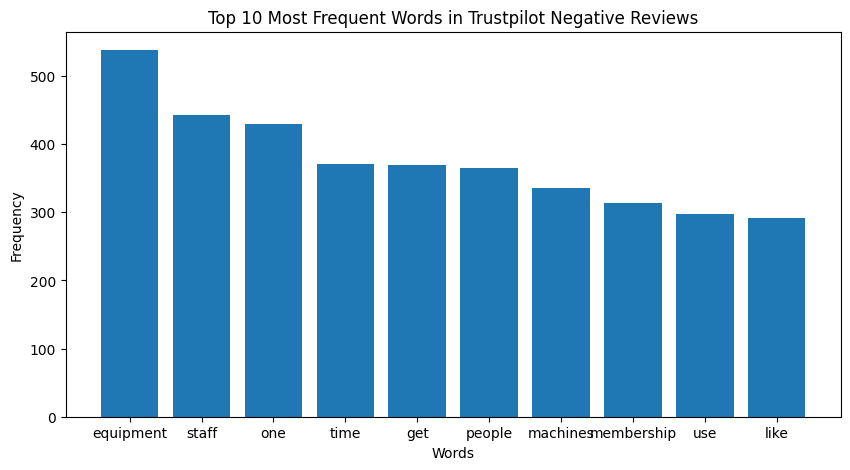

In [ ]:
# Split clean_review into tokens
all_words_tp_neg = " ".join(df_tpilot_negative['clean_review']).split()

# Create frequency distribution
freq_dist_tp_neg = FreqDist(all_words_tp_neg)

print(freq_dist_tp_neg.most_common(10))

# Get top 10 words
top_words_tp_neg = freq_dist_tp_neg.most_common(10)
words, counts = zip(*top_words_tp_neg)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words in Trustpilot Negative Reviews")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

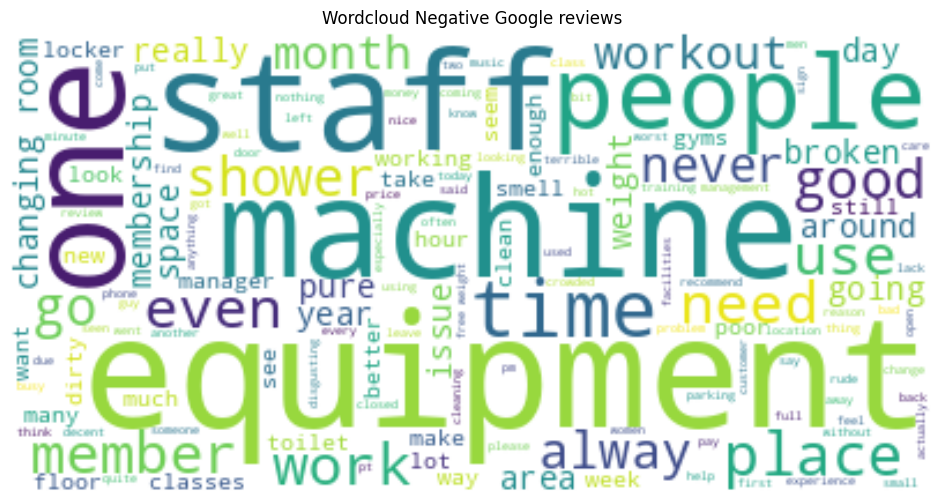

In [ ]:

# Join all cleaned reviews
text_goo_neg = " ".join(df_google_negative['clean_review'])

# Create word cloud
wordcloud_goo_neg = WordCloud(
    background_color="white",
    contour_color="black",
    contour_width=2
).generate(text_goo_neg)

# Plot
plt.figure(figsize=(12,6))
plt.title("Wordcloud Negative Google reviews")
plt.imshow(wordcloud_goo_neg, interpolation="bilinear")
plt.axis("off")
plt.show()

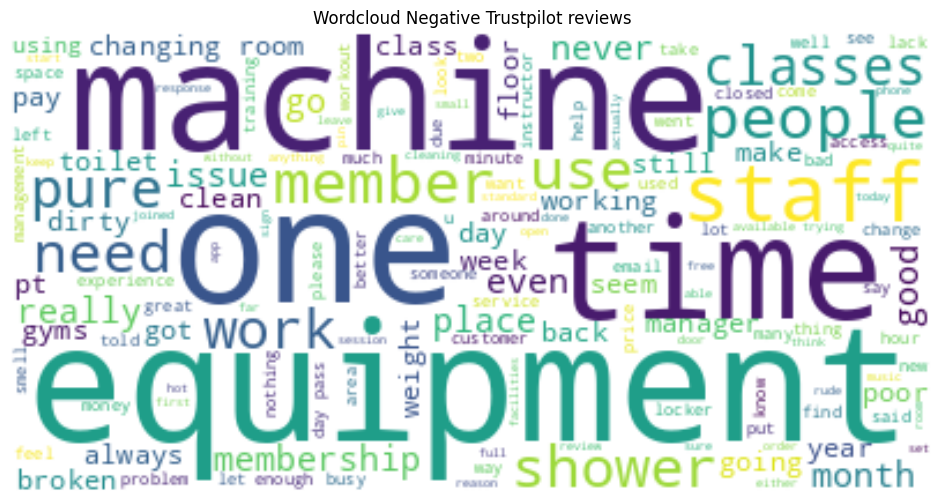

In [ ]:
# Join all cleaned reviews
text_tp_neg = " ".join(df_tpilot_negative['clean_review'])

# Create word cloud
wordcloud_tp_neg = WordCloud(
    background_color="white",
    contour_color="black",
    contour_width=2
).generate(text_tp_neg)

# Plot
plt.figure(figsize=(12,6))
plt.title("Wordcloud Negative Trustpilot reviews")
plt.imshow(wordcloud_tp_neg, interpolation="bilinear")
plt.axis("off")
plt.show()

## Merge Trustpilot and Google clean negative reviews

In [ ]:
# Rename columns in Trustpilot to match Google Reviews
df_tpilot_negative_renamed = df_tpilot_negative.rename(columns={
    "Review Content": "Comment",
    "Location Name": "Club's Name",
    "Review Stars": "Overall Score",
    "Review Date": "Creation Date",
    "Source Of Review": "Social Media Source"
})

# String constant for Social Media Source in Trustpilot data
df_tpilot_negative_renamed["Social Media Source"] = "Trustpilot"

# Now find common columns
common_cols = df_tpilot_negative_renamed.columns.intersection(df_google_negative.columns)
print(common_cols)

# Concatenate only common columns
merge_reviews = pd.concat([df_tpilot_negative_renamed[common_cols], df_google_negative[common_cols]], ignore_index=True)



Index(['Comment', 'Overall Score', 'Social Media Source', 'Club's Name',
       'is_common', 'clean_review'],
      dtype='object')


# 3. BERTopic Analysis - Stage 1: All Common Locations

### Key Findings

In [ ]:
# Rename columns in Trustpilot to match Google Reviews
df_tpilot_negative_renamed = df_tpilot_negative.rename(columns={
    "Review Content": "Comment",
    "Location Name": "Club's Name",
    "Review Stars": "Overall Score",
    "Review Date": "Creation Date",
    "Source Of Review": "Social Media Source"
})

# String constant for Social Media Source in Trustpilot data
df_tpilot_negative_renamed["Social Media Source"] = "Trustpilot"

# Now find common columns
common_cols = df_tpilot_negative_renamed.columns.intersection(df_google_negative.columns)
print(common_cols)

# Concatenate only common columns
merge_reviews = pd.concat([df_tpilot_negative_renamed[common_cols], df_google_negative[common_cols]], ignore_index=True)



Index(['Comment', 'Overall Score', 'Social Media Source', 'Club's Name',
       'is_common', 'clean_review'],
      dtype='object')


In [ ]:
pip install bertopic

In [ ]:
from bertopic import BERTopic

# Extract the reviews as a list
docs = merge_reviews["clean_review"].dropna().tolist()

In [ ]:
# Initialize BERTopic model
topic_model = BERTopic(language="english", calculate_probabilities=True)

# Fit the model on your reviews
topics, probs = topic_model.fit_transform(docs)


In [ ]:
#Reduce the number of topics to make the plots easier to interpret
topic_model.reduce_topics(docs, nr_topics=10)

## Topics identified

In [ ]:
#Show discovered topics
print(topic_model.get_topic_info().head(10))

# Show top words for a specific topic (e.g. topic 0)
print("Topic #1 Top Words: ",topic_model.get_topic(-1))
print("Topic #2 Top Words: ",topic_model.get_topic(0))

# Assign topics back to DataFrame
merge_reviews["topic"] = topics

   Topic  Count                                 Name  \
0     -1   1619      -1_equipment_staff_machines_one   
1      0    986      0_class_classes_equipment_staff   
2      1    694              1_air_showers_water_hot   
3      2    455            2_parking_day_pass_closed   
4      3     55                 3_go_worst_past_ever   
5      4     44       4_busy_crowded_overcrowded_way   
6      5     35         5_wifi_signal_terrible_place   
7      6     33  6_rude_staff_manager_unprofessional   
8      7     16     7_expensive_pure_avoid_sainsbury   
9      8     13       8_ceo_genocide_supports_israel   

                                      Representation  \
0  [equipment, staff, machines, one, people, like...   
1  [class, classes, equipment, staff, people, one...   
2  [air, showers, water, hot, dirty, equipment, c...   
3  [parking, day, pass, closed, code, pin, member...   
4  [go, worst, past, ever, terrible, never, nah, ...   
5  [busy, crowded, overcrowded, way, always, ma

## Intertopic distance map and topic word scores

In [ ]:
# Interactive topic overview
topic_model.visualize_topics()


In [ ]:
# Barchart: top words per topic
topic_model.visualize_barchart(n_words=5)

In [ ]:
# Heatmap: similarity between topics
topic_model.visualize_heatmap()

## Key findings

The most frequently occurring themes were:

Equipment & Classes (986 reviews) – concerns related to equipment availability, maintenance, and class experiences.
Facilities & Amenities (694 reviews) – complaints regarding air conditioning, showers, hot water, and general facility quality.
Parking & Access (455 reviews) – issues relating to parking availability, access restrictions, and gym closures.
Overcrowding (44 reviews) – concerns about busy gyms and limited equipment availability during peak periods.
Staff Behaviour (33 reviews) – reports of rude, unprofessional, or unhelpful staff interactions.

Several smaller niche topics were also identified, including Wi-Fi connectivity issues, pricing concerns, and isolated discussions unrelated to gym operations.

Overall, the analysis suggests that member dissatisfaction is primarily driven by operational issues rather than fitness offerings themselves.

# 5. Deep Dive: Top 30 Locations



## Location selection

In [ ]:
merge_reviews.head()

,Comment,Overall Score,Social Media Source,Club's Name,is_common,clean_review,topic
0,"Extremely busy, no fresh air.",1,Trustpilot,Sutton Times Square,1,extremely busy fresh air,34
1,The men’s changing rooms smell bad. They need ...,2,Trustpilot,Leeds City Centre South,1,men changing rooms smell bad need deep clean s...,-1
2,No one was cleaning the equipment after use. C...,1,Trustpilot,Dunfermline,1,one cleaning equipment use cleaning stations h...,-1
3,Not the best experience at 7am on a week day. ...,1,Trustpilot,Bristol Harbourside,1,best experience week day bought day pass recei...,2
4,Staff have their hands tied but surely head of...,1,Trustpilot,Sunderland,1,staff hands tied surely head office could brin...,-1


In [ ]:
#List out the top 20 locations with the highest number of negative reviews.

# Group by location and source
grouped = (
    merge_reviews.groupby(["Club's Name", "Social Media Source"])["Comment"]
            .count()
            .reset_index(name="num_comments")
)

# --- Google Top 20 ---
google_top20 = (
    grouped[grouped["Social Media Source"] == "Google Reviews"]
        .sort_values(by="num_comments", ascending=False)
        .head(20)
)

# --- Trustpilot Top 20 ---
trustpilot_top20 = (
    grouped[grouped["Social Media Source"] == "Trustpilot"]
        .sort_values(by="num_comments", ascending=False)
        .head(20)
)

common_top20 = google_top20["Club's Name"].isin(trustpilot_top20["Club's Name"])
intersection = google_top20[common_top20]

print("Top 20 Google locations:\n", google_top20)
print("\nTop 20 Trustpilot locations:\n", trustpilot_top20)
print("\nTop 20 common locations:\n", intersection)


Top 20 Google locations:
                   Club's Name Social Media Source  num_comments
366          London Stratford      Google Reviews            59
288       London Canary Wharf      Google Reviews            26
304            London Enfield      Google Reviews            25
370      London Swiss Cottage      Google Reviews            24
44     Birmingham City Centre      Google Reviews            21
340        London Leytonstone      Google Reviews            21
421                New Barnet      Google Reviews            20
563                 Wakefield      Google Reviews            19
64         Bradford Thornbury      Google Reviews            19
360      London Seven Sisters      Google Reviews            18
565       Walsall Crown Wharf      Google Reviews            18
328             London Hoxton      Google Reviews            18
399  Manchester Exchange Quay      Google Reviews            17
322              London Hayes      Google Reviews            17
454        Not

The top 20 locations with the highest number of negative reviews on Google and Trustpilot show limited overlap, sharing only 8 locations in common

In [ ]:
#Merge all reviews per club (ignoring source) and get Top 30
club_reviews_count = (
    merge_reviews[merge_reviews["Comment"].notna()]
      .groupby("Club's Name")["Comment"]
      .count()
      .reset_index(name="num_comments")
      .sort_values(by="num_comments", ascending=False)
)

print(club_reviews_count.head(30))

                   Club's Name  num_comments
190           London Stratford            81
131    Leicester Walnut Street            61
159             London Enfield            48
192       London Swiss Cottage            39
22      Birmingham City Centre            35
187       London Seven Sisters            34
146          London Bermondsey            34
219                 New Barnet            34
32          Bradford Thornbury            33
168               London Hayes            33
151        London Canary Wharf            32
292        Walsall Crown Wharf            31
46                     Burnham            30
167  London Hammersmith Palais            29
161            London Finchley            29
180        London Muswell Hill            28
202                 Maidenhead            26
21    Birmingham Beaufort Park            26
236         Nottingham Colwick            26
171              London Hoxton            26
11                    Basildon            26
291       

In [ ]:
#Compute top 30 clubs by review count
top30_clubs = (
    merge_reviews[merge_reviews["Comment"].notna()]
      .groupby("Club's Name")["Comment"]
      .count()
      .nlargest(30)              # top 30
      .index                     # club names
)

#Filter original merge reviews DataFrame
top30_reviews = merge_reviews[merge_reviews["Club's Name"].isin(top30_clubs)]

print(top30_clubs)

Index(['London Stratford', 'Leicester Walnut Street', 'London Enfield',
       'London Swiss Cottage', 'Birmingham City Centre', 'London Bermondsey',
       'London Seven Sisters', 'New Barnet', 'Bradford Thornbury',
       'London Hayes', 'London Canary Wharf', 'Walsall Crown Wharf', 'Burnham',
       'London Finchley', 'London Hammersmith Palais', 'London Muswell Hill',
       'Basildon', 'Birmingham Beaufort Park', 'London Hoxton', 'Maidenhead',
       'Nottingham Colwick', 'Wakefield', 'London Beckton', 'London Bromley',
       'London Holborn', 'London Leytonstone', 'London Park Royal', 'Chatham',
       'Leicester St Georges Way', 'Manchester Exchange Quay'],
      dtype='object', name='Club's Name')


In [ ]:
# Save results (Drive or local)
top30_reviews.to_parquet("/content/drive/MyDrive/top30_reviews.parquet", index=False)
print("Saved to Drive.")

Saved to Drive.


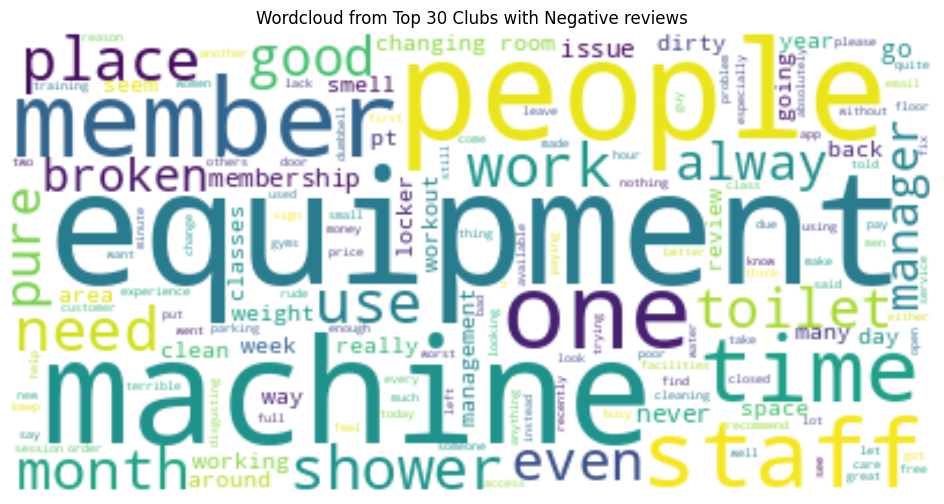

In [ ]:
# For the top 30 locations, redo the word cloud
#Join all cleaned reviews
text_top30_reviews = " ".join(top30_reviews['clean_review'])

# Create word cloud
wordcloud_top30_reviews = WordCloud(
    background_color="white",
    contour_color="black",
    contour_width=2
).generate(text_top30_reviews)

# Plot
plt.figure(figsize=(12,6))
plt.title("Wordcloud from Top 30 Clubs with Negative reviews")
plt.imshow(wordcloud_top30_reviews, interpolation="bilinear")
plt.axis("off")
plt.show()

[('equipment', 277), ('staff', 236), ('people', 235), ('one', 210), ('machines', 209), ('time', 192), ('get', 190), ('like', 165), ('even', 151), ('membership', 150)]


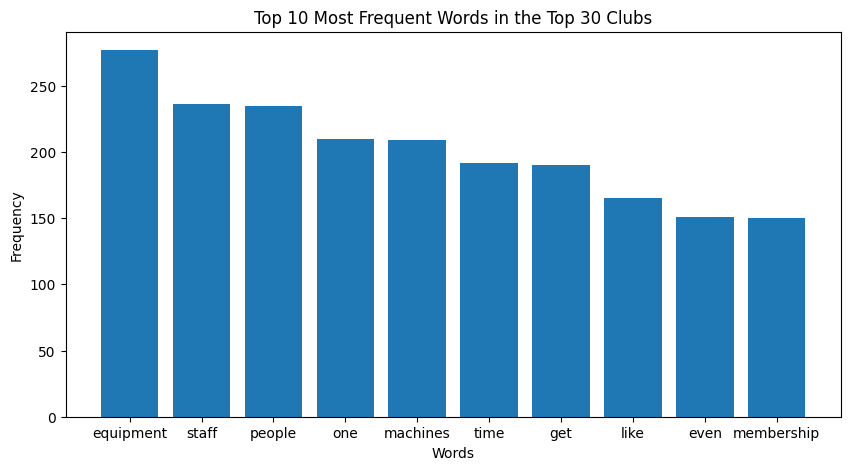

In [ ]:
# For the top 30 locations, redo the word frequency
# Split clean_review into tokens
all_words_top30_reviews = " ".join(top30_reviews['clean_review']).split()

# Create frequency distribution
freq_dist_top30_reviews = FreqDist(all_words_top30_reviews)

print(freq_dist_top30_reviews.most_common(10))

# Get top 10 words
top_words_top30_reviews = freq_dist_top30_reviews.most_common(10)
words, counts = zip(*top_words_top30_reviews)

plt.figure(figsize=(10,5))
plt.bar(words, counts)
plt.title("Top 10 Most Frequent Words in the Top 30 Clubs")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

In [ ]:

print('Top words previous Google reviews: ', top_words_g_neg)
print('Top words previous Trustpilot reviews: ', top_words_tp_neg)
print('Top words Top 30 merged reviews: ', top_words_top30_reviews)

g_words = [w for w, _ in top_words_g_neg]
tp_words = [w for w, _ in top_words_tp_neg]
top30_words = [w for w, _ in top_words_top30_reviews]

# Find intersection across all three
common_words = set(g_words) & set(tp_words) & set(top30_words)

print("Common words in all three lists:", common_words)

Top words previous Google reviews:  [('equipment', 770), ('staff', 588), ('people', 499), ('machines', 471), ('one', 466), ('time', 441), ('get', 392), ('like', 384), ('even', 347), ('place', 322)]
Top words previous Trustpilot reviews:  [('equipment', 538), ('staff', 443), ('one', 429), ('time', 371), ('get', 370), ('people', 365), ('machines', 335), ('membership', 313), ('use', 297), ('like', 292)]
Top words Top 30 merged reviews:  [('equipment', 277), ('staff', 236), ('people', 235), ('one', 210), ('machines', 209), ('time', 192), ('get', 190), ('like', 165), ('even', 151), ('membership', 150)]
Common words in all three lists: {'like', 'machines', 'people', 'staff', 'equipment', 'time', 'get', 'one'}


The word cloud and frequency analysis based on the Top 30 Clubs with negative reviews (merged) closely resemble the results from the initial run using Google and Trustpilot negative reviews. Notably, 8 out of the top 10 words appear consistently across all three lists.

## BERTopic results

In [ ]:


# Extract the reviews as a list
docs_top30 = top30_reviews["clean_review"].dropna().tolist()

# Initialize BERTopic model
topic_model_top30 = BERTopic(language="english", calculate_probabilities=True)

# Fit the model on your reviews
topics30, probs30 = topic_model_top30.fit_transform(docs_top30)

# Reduce the number of topics to 10
topic_model_top30 = topic_model_top30.reduce_topics(docs_top30, nr_topics=10)


In [ ]:
#Show discovered topics
print(topic_model_top30.get_topic_info().head(10))

   Topic  Count                                  Name  \
0     -1    261    -1_equipment_people_machines_staff   
1      0    195      0_showers_dirty_cleaning_toilets   
2      1    138         1_email_closed_membership_day   
3      2    138  2_machines_equipment_weights_lockers   
4      3     87           3_manager_rude_staff_member   
5      4     50         4_air_conditioning_hot_aircon   
6      5     39              5_parking_car_free_fines   
7      6     19        6_classes_class_session_booked   
8      7     15             7_water_sports_yanga_fill   
9      8     14               8_nis_prefer_never_good   

                                      Representation  \
0  [equipment, people, machines, staff, time, one...   
1  [showers, dirty, cleaning, toilets, shower, ch...   
2  [email, closed, membership, day, pin, get, mon...   
3  [machines, equipment, weights, lockers, people...   
4  [manager, rude, staff, member, reviews, pure, ...   
5  [air, conditioning, hot, aircon, 

## Intertopic Distance Map and topic word scores

In [ ]:
# Interactive topic overview
topic_model_top30.visualize_topics()

In [ ]:
# Barchart: top words per topic
topic_model_top30.visualize_barchart(n_words=5)

In [ ]:
# Heatmap: similarity between topics
topic_model_top30.visualize_heatmap()

## Key findings
The BERTopic analysis of reviews from the Top 30 locations revealed more granular and actionable themes than the initial analysis of all reviews

The largest identified topics were:

Showers & Cleanliness (195 reviews) – complaints regarding dirty showers, toilets, changing areas, and inadequate cleaning standards.
Membership & Access Issues (138 reviews) – difficulties with memberships, access codes, gym closures, and customer communications.
Equipment & Locker Issues (138 reviews) – concerns about broken machines, equipment availability, weights, and locker facilities.
Staff Behaviour & Management (87 reviews) – reports of rude staff, poor customer service, and management-related issues.
Air Conditioning & Facilities (50 reviews) – complaints about hot gym environments and inadequate ventilation.
Parking & Fines (39 reviews) – frustrations relating to parking restrictions and penalty charges.

Smaller but still relevant themes included class booking problems, water machine availability, and sports drink services.

# 6. Emotion Analysis

## Emotion Classification

## Emotion Distribution

## BERTopic on Angry Reviews

## Key Findings

## Emotion Classification

In [ ]:
from transformers import pipeline

# Load the pipeline for text classification
classifier = pipeline(
    "text-classification",
    model="bhadresh-savani/bert-base-uncased-emotion",
    return_all_scores=True   # optional: returns probabilities for all emotions
)

# Example text
texts = [
    "I love going to the gym, it makes me so happy!",
    "The staff were rude and unprofessional.",
    "The showers are always cold, really frustrating."
]

# Run classification
results = classifier(texts)

# Display results
for text, res in zip(texts, results):
    print(f"\nText: {text}")
    for r in res:
        print(f"  {r['label']}: {r['score']:.4f}")

config.json:   0%|          | 0.00/935 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu



Text: I love going to the gym, it makes me so happy!
  sadness: 0.0005
  joy: 0.9987
  love: 0.0004
  anger: 0.0002
  fear: 0.0001
  surprise: 0.0002

Text: The staff were rude and unprofessional.
  sadness: 0.0004
  joy: 0.0002
  love: 0.0006
  anger: 0.9978
  fear: 0.0006
  surprise: 0.0004

Text: The showers are always cold, really frustrating.
  sadness: 0.0014
  joy: 0.0002
  love: 0.0005
  anger: 0.9962
  fear: 0.0014
  surprise: 0.0002


In [ ]:
print(merge_reviews.shape)

(3950, 7)


In [ ]:
# Load the Hugging Face emotion classifier
classifier = pipeline(
    "text-classification",
    model="bhadresh-savani/bert-base-uncased-emotion",
    return_all_scores=False   # only top predicted emotion
)

# Apply to the merged negative reviews dataframe
def get_emotion(text):
    if pd.isna(text):   # handle missing values
        return None
    result = classifier(text[:512])  # truncate to 512 tokens (BERT limit)
    return result[0]['label']

# Take 50% sample of merge reviews
merge_reviews50pct = merge_reviews.sample(frac=0.5, random_state=42)

# Add a new column with the predicted emotion
merge_reviews50pct["predicted_emotion"] = merge_reviews50pct["Comment"].apply(get_emotion)

# Check results
print(merge_reviews50pct[["Comment", "predicted_emotion"]].head(10))

Device set to use cpu


                                                Comment predicted_emotion
3136  I give zero if I could . I have booked 1-2-1 s...           sadness
2118                                         Rude staff             anger
1811  This is a very poorly managed gym . Constantly...               joy
70    Made a mistake in the package I opted for. tri...               joy
2609  Really good gym in terms of equipment, tonnes ...             anger
3295  2023 and this gym doesn’t have working wifi. C...               joy
1694                                Scam charged me 70£             anger
3310  It's always been a problem with the size of th...              fear
270   Got charged twice couldn’t get a refund gym wa...               joy
1270  New gym, new staff… although there are cleaner...               joy


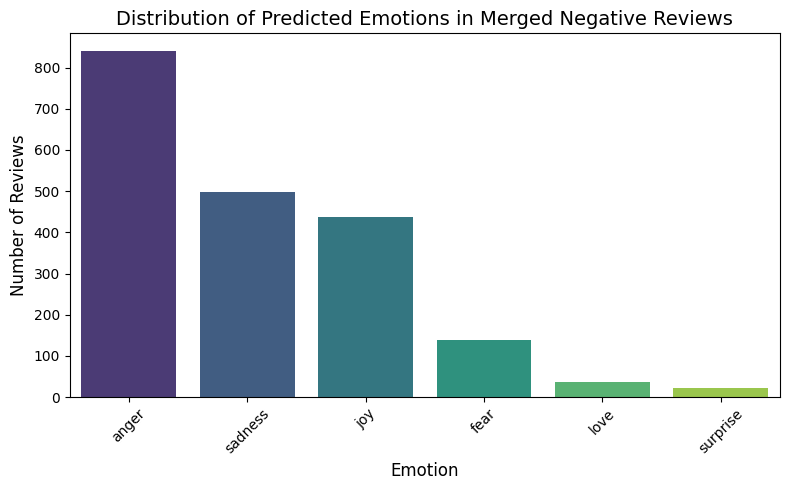

In [ ]:
import seaborn as sns

# Count how many reviews per predicted emotion
emotion_counts = merge_reviews50pct["predicted_emotion"].value_counts()

# Plot
plt.figure(figsize=(8,5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="viridis")

plt.title("Distribution of Predicted Emotions in Merged Negative Reviews", fontsize=14)
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Filter reviews where anger is the top predicted emotion
anger_reviews = merge_reviews50pct[merge_reviews50pct["predicted_emotion"] == "anger"]

# Check first rows
print(anger_reviews[["Comment","clean_review", "predicted_emotion"]].head(10))

# Count how many
print(f"\nTotal anger reviews: {len(anger_reviews)}")

                                                Comment  \
2118                                         Rude staff   
2609  Really good gym in terms of equipment, tonnes ...   
1694                                Scam charged me 70£   
3808  Just did a day pass at a pricey £7.99 as I'm l...   
2754  The gym is a good size, nice atmosphere. Plent...   
568   No parking spaces at all. People had to park o...   
1263  I transfered to EldonGardens - Newcastle and f...   
787   Toilets and shower area and changing rooms are...   
321     The 8 digit pin did not work at noniminated gym   
2045                                                Nis   

                                           clean_review predicted_emotion  
2118                                         rude staff             anger  
2609  really good terms equipment tonnes racks bench...             anger  
1694                                       scam charged             anger  
3808  day pass pricey looking switching gyms t

## BERTopic results on angry reviews

In [ ]:
from bertopic import BERTopic

# Extract the reviews as a list
docs_anger2 = anger_reviews["clean_review"].dropna().tolist()


# Initialize BERTopic model
#topic_model_anger = BERTopic(language="english", calculate_probabilities=True)
topic_model_anger2 = BERTopic(language="english", calculate_probabilities=True, min_topic_size=10)

# Fit the model on your reviews
topics_anger2, probs_anger2 = topic_model_anger2.fit_transform(docs_anger2)


In [ ]:

# Reduce the number of topics to 10
topic_model_anger2 = topic_model_anger2.reduce_topics(docs_anger2, nr_topics=10)

In [ ]:
#Show discovered topics
print(topic_model_anger2.get_topic_info().head(10))

   Topic  Count                               Name  \
0     -1    226       -1_staff_people_machines_use   
1      0    192      0_showers_cold_changing_water   
2      1    130        1_membership_pass_day_email   
3      2    117             2_staff_class_one_rude   
4      3     74  3_equipment_weights_machines_busy   
5      4     26           4_parking_park_fine_free   
6      5     25    5_music_loud_classes_headphones   
7      6     21          6_crowded_cap_busy_people   
8      7     18         7_air_conditioning_ac_cold   
9      8     12         8_worst_ever_rubbish_worse   

                                      Representation  \
0  [staff, people, machines, use, equipment, get,...   
1  [showers, cold, changing, water, rooms, shower...   
2  [membership, pass, day, email, get, closed, pi...   
3  [staff, class, one, rude, manager, said, membe...   
4  [equipment, weights, machines, busy, weight, p...   
5  [parking, park, fine, free, car, using, people...   
6  [music, lo

## Interpoic Distance map and Topic Word scores on Angry reviews

In [ ]:
# Interactive topic overview
topic_model_anger2.visualize_topics()

In [ ]:
# Barchart: top words per topic
topic_model_anger2.visualize_barchart(n_words=5)

In [ ]:
# Heatmap: similarity between topics
topic_model_anger2.visualize_heatmap()

## Key findings

To better understand the drivers of strong negative sentiment, BERTopic was applied exclusively to reviews classified as expressing anger.

The results reveal that the causes of anger differ slightly from general dissatisfaction. While equipment and facilities remain important, the strongest emotional reactions are associated with issues that directly disrupt the member experience.

**From a business perspective, these topics represent high-priority service failures because they are more likely to generate membership cancellations**

The largest topics identified were:

Showers, Changing Rooms & Water Issues (192 reviews) – complaints regarding cold showers, changing facilities, and lack of hot water.
Membership & Access Problems (130 reviews) – frustrations with memberships, day passes, emails, account management, and gym access.
Staff & Class Experience (117 reviews) – reports of rude staff, poor customer interactions, and negative class experiences.
Equipment & Busyness (74 reviews) – concerns about equipment availability, overcrowding, and waiting times.
Parking & Fines (26 reviews) – dissatisfaction relating to parking restrictions and penalty charges.

# 7. LLM-Enhanced Topic Modelling

## BART-MNLI Classification

## BERTopic Clustering

## GPT Topic Extraction Pipeline

## Business Recommendations

## Key Findings

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load parquet file from Drive
top30_reviews = pd.read_parquet("/content/drive/MyDrive/top30_reviews.parquet")

# Check the first rows
print(top30_reviews.head())

                                             Comment  Overall Score  \
0  awful experience joining. won’t let me get on ...              1   
1  Is pure gym staff allowed to blame or annoying...              1   
2  Gym is too full, impossible to find available ...              2   
3                             Worse gym in Leicester              1   
4  Smelt really bad / sweaty and was a lot smalle...              1   

  Social Media Source               Club's Name  is_common  \
0          Trustpilot           London Finchley          1   
1          Trustpilot             London Hoxton          1   
2          Trustpilot          London Stratford          1   
3          Trustpilot  Leicester St Georges Way          1   
4          Trustpilot        Nottingham Colwick          1   

                                        clean_review  topic  
0  awful experience joining let get buddy members...     29  
1  pure staff allowed blame annoying people hoxto...      5  
2  full imposs

In [ ]:
top30_reviews.shape

(956, 7)

In [ ]:
from transformers import pipeline
import pandas as pd

# Zero-shot-classification pipeline
classifier = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Candidate topics
candidate_topics = [
        "The showers and the overall cleanliness are disappointing",
        "Many of the machines are broken or outdated",
        "The staff were rude and unhelpful",
        "Parking is always a struggle",
        "The gym was too hot",
        "The gym is constantly overcrowded",
        "I had trouble with my membership",
        "The group classes are not well-organized",
        "The WiFi is unreliable",
        "The membership fees are too high for the value offered",
        "No access to water or sports drinks",
        "Lockers do not work properly",
        "The music is too loud",
        "I’m concerned about stance on certain political ethical issues",
    ]

# Take 50% sample of reviews
sampled_reviews = top30_reviews.sample(frac=0.99, random_state=42)

# Convert comments into a list
reviews_list = sampled_reviews["Comment"].tolist()

# Run classifier in batch (8 reviews at a time), single topic per review
results = classifier(
    sequences=reviews_list,
    candidate_labels=candidate_topics,
    multi_label=True,  # Only one topic per review
    batch_size=8
)

# Extract top topic for each review (as a string)
sampled_reviews["topic"] = [res["labels"][:3] for res in results]

# Show results
print(sampled_reviews[["Comment", "topic"]].head())

# Save results (Drive or local)
sampled_reviews.to_parquet("/content/drive/MyDrive/sampled_reviews.parquet", index=False)
print("Saved to Drive.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


                                               Comment  \
342  Disgusting and smelly changing room and WC are...   
864  Horrendously busy unless you like to workout a...   
522  In keeping with the Puregym app's general nose...   
544  This is the worst puregym I've ever been to. T...   
682  No matter what time it is, this gym is always ...   

                                                 topic  
342  [The showers and the overall cleanliness are d...  
864  [The gym is constantly overcrowded, Parking is...  
522  [The showers and the overall cleanliness are d...  
544  [The showers and the overall cleanliness are d...  
682  [The gym is constantly overcrowded, Many of th...  
Saved to Drive.


In [ ]:
from bertopic import BERTopic

#Let's run BERtopic on the LLM reviews

sampled_reviews["topic_str"] = sampled_reviews["topic"].apply(lambda x: x[0] if isinstance(x, list) else x)

# Extract the reviews as a list
docs_llm = sampled_reviews["topic_str"].dropna().tolist()

# Initialize BERTopic model
topic_model_llm = BERTopic(language="english", calculate_probabilities=True)

# Fit the model on your reviews
topics30, probs30 = topic_model_llm.fit_transform(docs_llm)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 12.5 MB/s eta 0:00:00


In [ ]:
#Reduce the number of topics to make the plots easier to interpret
topic_model_llm.reduce_topics(docs_llm, nr_topics=10)

In [ ]:
#Show discovered topics
print(topic_model_llm.get_topic_info().head(10))

   Topic  Count                                         Name  \
0      0    278              0_many_broken_outdated_machines   
1      1    172                 1_membership_my_trouble_with   
2      2    143                  2_rude_unhelpful_were_staff   
3      3    139  3_disappointing_showers_cleanliness_overall   
4      4    131              4_gym_constantly_overcrowded_is   
5      5     19            5_wellorganized_classes_group_not   
6      6     18                   6_properly_lockers_do_work   
7      7     16                 7_always_struggle_parking_is   
8      8     15                     8_water_to_access_drinks   
9      9     15                     9_unreliable_wifi_is_had   

                                      Representation  \
0  [many, broken, outdated, machines, of, or, are...   
1  [membership, my, trouble, with, had, fees, val...   
2  [rude, unhelpful, were, staff, and, the, issue...   
3  [disappointing, showers, cleanliness, overall,...   
4  [gym, consta

In [ ]:
# Interactive topic overview
topic_model_llm.visualize_topics()

In [ ]:
# Barchart: top words per topic
topic_model_llm.visualize_barchart(n_words=5)

In [ ]:
# Heatmap: similarity between topics
topic_model_llm.visualize_heatmap()

## Key findings

Constant Topics (appear in both Top 30 BERT and LLM+BERT):
	Showers/cleanliness
	Membership issues
	Equipment/machines
	Staff rudeness
	Parking
	Water/drinks access

Partially Overlapping Topics:
	Air conditioning/temperature vs. overcrowding/hot gym
	Classes (BERT: booking; LLM+BERT: organization)
	Lockers (BERT: with equipment; LLM+BERT: as a distinct topic)

Unique Topics:
	LLM+BERT only: Wifi issues


# 8. Gensim LDA Topic Modelling



In [ ]:
# Install gensim if needed
!pip install gensim

import pandas as pd
import gensim
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk

# Download NLTK resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab") # Added punkt_tab download

# 1. Prepare stopwords
stop_words = set(stopwords.words("english"))
# Add custom ones
custom_stopwords = {"gym", "puregym"}
stop_words.update(custom_stopwords)

# 2. Tokenize and clean comments
def preprocess(text):
    tokens = word_tokenize(str(text).lower())
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    return tokens

# Apply preprocessing
top30_reviews["tokens"] = top30_reviews["Comment"].apply(preprocess)

# 3. Build dictionary and corpus
dictionary = corpora.Dictionary(top30_reviews["tokens"])
corpus = [dictionary.doc2bow(text) for text in top30_reviews["tokens"]]

# 4. Train LDA model (10 topics)
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10,
    random_state=42,
    passes=10,
    per_word_topics=True
)

# 5. Show topics
topics = lda_model.print_topics(num_words=5)
for idx, topic in topics:
    print(f"Topic {idx+1}: {topic}")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Topic 1: 0.015*"equipment" + 0.010*"machines" + 0.010*"staff" + 0.009*"use" + 0.008*"people"
Topic 2: 0.011*"machine" + 0.011*"one" + 0.009*"machines" + 0.009*"people" + 0.008*"always"
Topic 3: 0.018*"parking" + 0.009*"pure" + 0.009*"membership" + 0.006*"would" + 0.006*"first"
Topic 4: 0.009*"people" + 0.008*"equipment" + 0.007*"staff" + 0.007*"showers" + 0.007*"time"
Topic 5: 0.011*"equipment" + 0.009*"weights" + 0.009*"manager" + 0.007*"really" + 0.007*"one"
Topic 6: 0.010*"membership" + 0.007*"parking" + 0.007*"get" + 0.007*"people" + 0.007*"member"
Topic 7: 0.010*"broken" + 0.009*"machines" + 0.007*"gyms" + 0.007*"staff" + 0.007*"would"
Topic 8: 0.009*"staff" + 0.008*"changing" + 0.008*"day" + 0.006*"get" + 0.006*"email"
Topic 9: 0.008*"people" + 0.008*"rude" + 0.007*"members" + 0.007*"manager" + 0.007*"get"
Topic 10: 0.013*"equipment" + 0.008*"people" + 0.007*"machines" + 0.007*"toilets" + 0.007*"one"


In [ ]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

pyLDAvis.enable_notebook()

# Prepare interactive visualization
lda_vis = gensimvis.prepare(lda_model, corpus, dictionary)
lda_vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.043715  0.011736       1        1  25.207962
3      0.019444  0.018780       2        1  12.504144
7     -0.019636  0.038993       3        1  11.768636
9      0.036412  0.007222       4        1   9.163639
1      0.063442  0.026810       5        1   8.999389
5     -0.095502 -0.134443       6        1   8.046629
2     -0.150452  0.089129       7        1   7.795390
4      0.046305 -0.042643       8        1   5.871550
8      0.019540 -0.060521       9        1   5.525840
6      0.036733  0.044937      10        1   5.116822, topic_info=           Term        Freq       Total Category  logprob  loglift
1028    parking   83.000000   83.000000  Default  30.0000  30.0000
96    equipment  247.000000  247.000000  Default  29.0000  29.0000
345      broken  107.000000  107.000000  Default  28.0000  28.0000
529    machines  185.000000  185.000000  Default  27.0000  27.0000
207     machine   93.000000   93.000000  Default  26.0000  26.0000
...         ...         ...         ...      ...      ...      ...
910     manager    4.971618   98.642668  Topic10  -5.7603  -0.0151
73       people    5.546925  206.215341  Topic10  -5.6508  -0.6430
769        open    4.316281   43.791280  Topic10  -5.9017   0.6556
18          get    4.679718  166.759825  Topic10  -5.8208  -0.6007
96    equipment    4.705927  247.581415  Topic10  -5.8152  -0.9903

[806 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
682       6  0.794257   abdominal
2198      2  0.765367     absence
0         1  0.026450  absolutely
0         2  0.052901  absolutely
0         3  0.343855  absolutely
...     ...       ...         ...
1605     10  0.052390       years
3824      5  0.790482           z
2980     10  0.844626       zenga
3244      1  0.241249       zumba
3244      9  0.482498       zumba

[2086 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 4, 8, 10, 2, 6, 3, 5, 9, 7])

## Key findings - Interpretation of the 10 Gemsin Topics

Topic 1 → Equipment & usage
equipment, machines, staff, use, people → complaints about equipment availability/condition and staff support.

Topic 2 → Machine availability / overcrowding
machine, one, machines, people, always → people struggling to get a machine because it’s too busy.

Topic 3 → Parking & membership issues
parking, membership, first → frustration with parking and signup/membership process.

Topic 4 → Facilities & cleanliness
people, equipment, staff, showers, time → mentions of showers, staff, and overall facility use.

Topic 5 → Free weights & management
equipment, weights, manager → concerns about free weights area and poor management.

Topic 6 → Membership & parking
membership, parking, member → overlaps with Topic 3, but focused on the membership experience.

Topic 7 → Broken machines
broken, machines, gyms, staff → equipment not being fixed, maybe poor maintenance.

Topic 8 → Staff communication / changing rooms
staff, changing, day, email → staff behaviour, changing rooms, and communication (emails).

Topic 9 → Rude staff & managers
people, rude, members, manager → complaints about how staff/managers treat members.

Topic 10 → Equipment & toilets
equipment, people, machines, toilets → equipment plus toilet facilities.

So broadly,  3 main themes:

Equipment & machines (availability, broken, weights).

Staff & management behaviour (rude staff, poor communication, bad managers).

Facilities & membership (parking, showers, toilets, membership process).

# 9. Cross-Experiment Comparison


## Topic Comparison Across Models

| Model / Stage                           | Key Topics Identified                                                                                         |
| --------------------------------------- | ------------------------------------------------------------------------------------------------------------- |
| **BERTopic Stage 1** (All Reviews)      | Equipment & Classes, Facilities & Cleanliness, Parking & Access, Overcrowding, Staff Behaviour, WiFi, Pricing |
| **BERTopic Stage 2** (Top 30 Locations) | Showers & Cleanliness, Membership & Access, Equipment & Lockers, Staff Management, Air Conditioning, Parking  |
| **BERTopic Stage 3** (Angry Reviews)    | Showers & Changing Rooms, Membership Issues, Staff Behaviour, Equipment & Busyness, Parking Fines, Noise      |
| **LLM + BERTopic**                      | Broken Machines, Membership Fees, Rude Staff, Showers & Cleanliness, Overcrowding, Lockers, WiFi              |
| **Gensim LDA**                          | Equipment Usage, Overcrowding, Parking, Membership, Facilities, Staff Behaviour, Toilets                      |

---

# Consistent Findings Across All Models

Despite differences in methodology, three major themes appeared consistently across all experiments.

### 🏋️ Equipment & Machines

* Equipment availability
* Broken machines
* Free weights access
* Overcrowding around equipment

**Appeared in:** BERTopic, LLM + BERTopic, and Gensim LDA

---

### 👥 Staff & Management

* Rude or unhelpful staff
* Poor complaint handling
* Weak management oversight
* Customer service concerns

**Appeared in:** BERTopic Stage 1, Stage 2, Stage 3, LLM + BERTopic, and Gensim LDA

---

### 🚿 Facilities & Membership Issues

* Showers and cleanliness
* Air conditioning
* Toilets and changing rooms
* Parking and access
* Membership administration

**Appeared in:** All modelling approaches

---

# Unique Insights by Method

### BERTopic Stage 1

* Surfaced ethical/political concerns
* Identified pricing and value complaints
* Highlighted WiFi issues

### BERTopic Stage 2 - Top 30 locations

* Revealed operational issues such as lockers, air conditioning, and parking fines
* Produced the most actionable facility-level insights

### BERTopic Stage 3 (Angry Reviews)

* Identified the strongest emotional triggers
* Surfaced music and noise complaints
* Highlighted cold showers and membership access as major sources of frustration

### LLM + BERTopic

* Produced business-oriented topics and recommendations
* Identified locker and WiFi issues more clearly
* Generated actionable improvement suggestions

### Gensim LDA

* Fastest and simplest approach
* Confirmed the major themes found by BERTopic
* Produced broader, less granular topics

---

# Overall Conclusion

The consistency of findings across BERTopic, LLM-enhanced topic modelling, and Gensim LDA increases confidence in the results. Equipment availability, staff interactions, and facility quality emerged as the most important drivers of member dissatisfaction and represent the clearest opportunities for improving customer experience and retention.
